# Árboles de Decisión — Riesgo Operativo

**SI3015 - Fundamentos de Aprendizaje Automático**

En este cuaderno entrenaremos un Random Forest junto con un Gradient Boosting para predecir el **riesgo operativo final** (`riesgo_final`) a partir del dataset de riesgo operativo.

In [3]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [4]:
# Definamos el `random_state`:
random_state = 42

In [5]:
# Cambiemos la fuente de las gráficas de matplotlib:
plt.rc('font', family='serif', size=12)

In [6]:
# Carguemos los datos:
data = pd.read_csv('dataset_riesgo_operativo_limpio.csv')
data

,equipo,semana,t_prom,pct_fuera,pct_cumplimiento,interaccion,des_carga,correcciones,riesgo_final,riesgo_alto
0,1,1,4.370861,0.570429,0.839196,71.906094,0.078009,2,0.280227,0
1,1,2,4.003378,0.085720,0.790533,33.948811,0.360999,13,0.309325,0
2,1,3,2.911052,0.109095,0.510043,51.296957,0.262378,11,0.360259,1
3,1,4,4.598749,0.027999,0.984253,46.293994,0.045303,13,0.187575,0
4,1,5,2.797064,0.308541,0.755449,33.251529,0.303772,4,0.277347,0
...,...,...,...,...,...,...,...,...,...,...
175,15,8,6.828163,0.356638,0.630167,34.593830,0.410756,14,0.524315,1
176,15,9,5.397789,0.462244,0.809977,61.213189,0.136813,12,0.398433,1
177,15,10,8.433287,0.179025,0.903968,84.097595,0.115027,10,0.266324,0
178,15,11,3.459336,0.570518,0.490635,60.263436,0.471808,15,0.614510,1


In [7]:
# Veamos la descripción del dataset:
data.describe(include='all')

,equipo,semana,t_prom,pct_fuera,pct_cumplimiento,interaccion,des_carga,correcciones,riesgo_final,riesgo_alto
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,8.000000,6.500000,5.877457,0.304946,0.679121,63.042794,0.247122,7.422222,0.334727,0.500000
std,4.332545,3.461682,2.460051,0.168282,0.174391,20.175366,0.141877,4.618345,0.103613,0.501395
min,1.000000,1.000000,1.023355,0.000312,0.400143,30.189763,0.006836,0.000000,0.111088,0.000000
25%,4.000000,3.750000,3.841115,0.161050,0.524306,46.597568,0.120051,3.000000,0.256864,0.000000
50%,8.000000,6.500000,5.911352,0.317390,0.675501,63.236264,0.253393,7.000000,0.340032,0.500000
75%,12.000000,9.250000,7.830422,0.446607,0.821863,81.610983,0.361886,11.000000,0.401670,1.000000
max,15.000000,12.000000,9.962482,0.598760,0.999831,99.781198,0.495738,15.000000,0.616250,1.000000


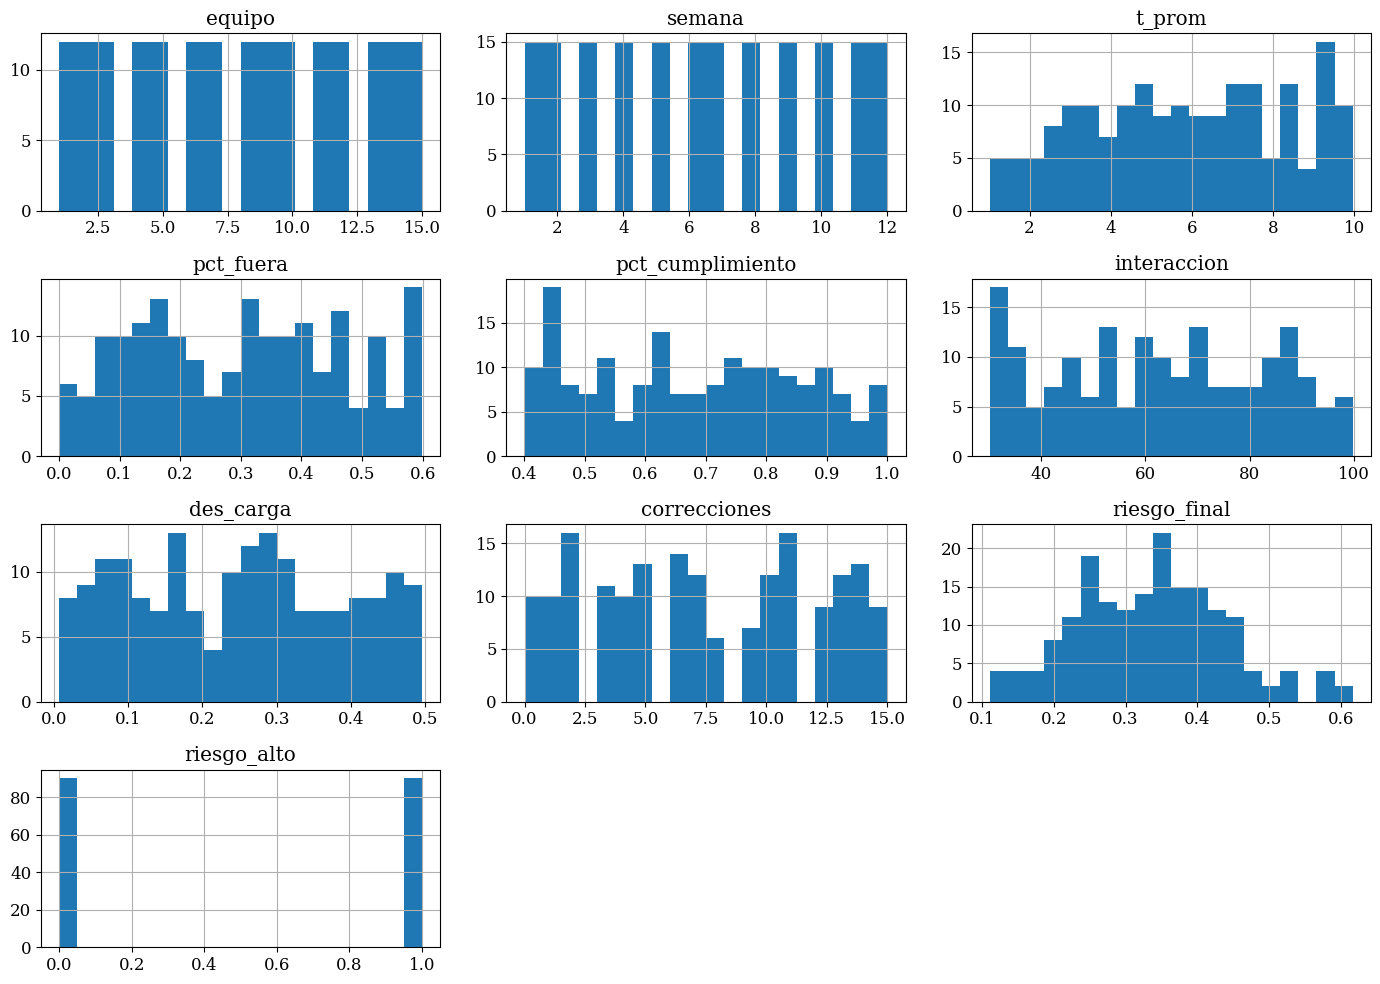

In [8]:
# Visualicemos la distribución de las variables numéricas:
data.hist(bins=20, figsize=(14, 10))
plt.tight_layout()

In [9]:
# Revisemos la distribución de correcciones:
data['correcciones'].describe()

count    180.000000
mean       7.422222
std        4.618345
min        0.000000
25%        3.000000
50%        7.000000
75%       11.000000
max       15.000000
Name: correcciones, dtype: float64

In [10]:
# Verifiquemos si hay registros con valores anómalos en interaccion:
data[data['interaccion'] < 0]

,equipo,semana,t_prom,pct_fuera,pct_cumplimiento,interaccion,des_carga,correcciones,riesgo_final,riesgo_alto


In [11]:
# Definamos features y variable objetivo:
# Excluimos 'riesgo_alto' porque es derivada de 'riesgo_final'
feature_cols = ['t_prom', 'pct_fuera', 'pct_cumplimiento', 'interaccion', 'des_carga', 'correcciones']
X = data[feature_cols]
y = data['riesgo_final']

print(f'Features: {feature_cols}')
print(f'X shape: {X.shape}, y shape: {y.shape}')

Features: ['t_prom', 'pct_fuera', 'pct_cumplimiento', 'interaccion', 'des_carga', 'correcciones']
X shape: (180, 6), y shape: (180,)


In [12]:
# Separemos en entrenamiento y prueba:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)

In [13]:
# Definamos nuestros regresores base:
rf_base = RandomForestRegressor(random_state=random_state)
gb_base = GradientBoostingRegressor(random_state=random_state)

pipeline_rf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('regressor', rf_base),
])

pipeline_gb = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('regressor', gb_base),
])

# Definamos la malla de parámetros sobre la que haremos la búsqueda:
param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': list(range(3, 7)),
    'regressor__min_samples_leaf': [2, 5, 10]
}

# Definamos nuestros modelos mediante GridSearchCV:
rf = GridSearchCV(pipeline_rf, cv=3, param_grid=param_grid)
gb = GridSearchCV(pipeline_gb, cv=3, param_grid=param_grid)

In [14]:
%%time
# Entrenemos el random forest:
rf.fit(X_train, y_train)
# Entrenemos el gradient boosting:
gb.fit(X_train, y_train)

CPU times: total: 10.6 s
Wall time: 11.3 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__max_depth': [3, 4, ...], 'regressor__min_samples_leaf': [2, 5, ...], 'regressor__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [15]:
print(rf.best_params_)
print(gb.best_params_)

{'regressor__max_depth': 6, 'regressor__min_samples_leaf': 2, 'regressor__n_estimators': 100}
{'regressor__max_depth': 3, 'regressor__min_samples_leaf': 10, 'regressor__n_estimators': 100}


In [16]:
# Obtengamos el R^2 y el MAE de entrenamiento para cada modelo:
print('Train set')
for model in (rf, gb):
    print(f"Model: {'Random Forest' if model == rf else 'Gradient Boosting'}")
    print(f'R^2: {model.score(X_train, y_train)}')
    print(f'MAE: {mean_absolute_error(y_train, model.predict(X_train))}')
    print('\n')

print('Test set')
for model in (rf, gb):
    print(f"Model: {'Random Forest' if model == rf else 'Gradient Boosting'}")
    print(f'R^2: {model.score(X_test, y_test)}')
    print(f'MAE: {mean_absolute_error(y_test, model.predict(X_test))}')
    print('\n')

Train set
Model: Random Forest
R^2: 0.9581475456881163
MAE: 0.016207879831988386


Model: Gradient Boosting
R^2: 0.9858307518307736
MAE: 0.009337584362194907


Test set
Model: Random Forest
R^2: 0.8119472067410367
MAE: 0.0397816380426987


Model: Gradient Boosting
R^2: 0.896963930442727
MAE: 0.028442123182347415




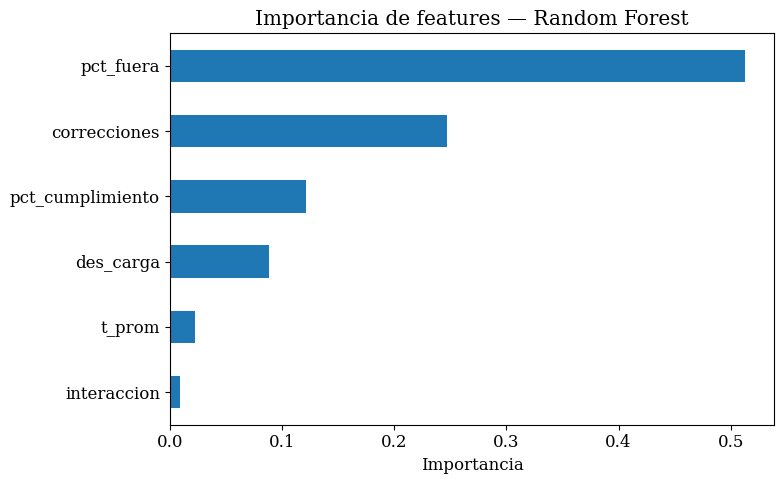

In [17]:
# Importancia de features según Random Forest:
importances = rf.best_estimator_['regressor'].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots()
feat_imp.plot(kind='barh', ax=ax)
ax.set_title('Importancia de features — Random Forest')
ax.set_xlabel('Importancia')
fig.set_size_inches(8, 5)
plt.tight_layout()

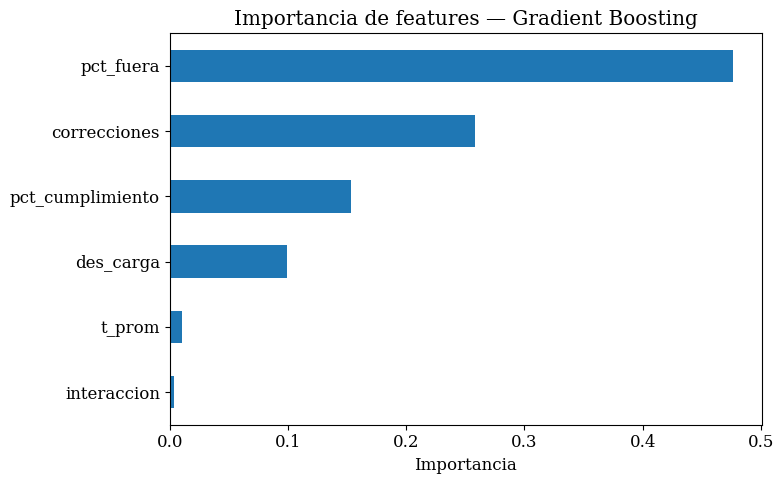

In [18]:
# Importancia de features según Gradient Boosting:
importances_gb = gb.best_estimator_['regressor'].feature_importances_
feat_imp_gb = pd.Series(importances_gb, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots()
feat_imp_gb.plot(kind='barh', ax=ax)
ax.set_title('Importancia de features — Gradient Boosting')
ax.set_xlabel('Importancia')
fig.set_size_inches(8, 5)
plt.tight_layout()